In [1]:
import os, duckdb, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
con = duckdb.connect("data/processed/criteo.duckdb")
OUT = "module_1_criteo/outputs/"

IOException: IO Error: Could not set lock on file "/Users/srilathajuvvadi/growth-marketing-analytics/data/processed/criteo.duckdb": Conflicting lock is held in /opt/anaconda3/bin/python3.13 (PID 49520) by user srilathajuvvadi. See also https://duckdb.org/docs/stable/connect/concurrency

In [1]:
import sys; print(sys.executable)

/Users/srilathajuvvadi/growth-marketing-analytics/.venv/bin/python


In [2]:
import os, duckdb, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
con = duckdb.connect("data/processed/criteo.duckdb")
OUT = "module_1_criteo/outputs/"

Matplotlib is building the font cache; this may take a moment.


In [3]:
con.execute("""
CREATE OR REPLACE TABLE campaign_perf AS
SELECT
  campaign,
  COUNT(*)                                   AS impressions,
  SUM(click)                                 AS clicks,
  SUM(cost)                                  AS spend,
  COUNT(DISTINCT CASE WHEN conversion_id <> -1 THEN conversion_id END) AS conversions,
  COUNT(DISTINCT uid)                        AS reach
FROM raw GROUP BY campaign
""")
df = con.sql("SELECT * FROM campaign_perf").df()

df["ctr"]       = df.clicks / df.impressions
df["cpc"]       = df.spend / df.clicks.replace(0, pd.NA)
df["cpm"]       = df.spend * 1000 / df.impressions
df["cvr"]       = df.conversions / df.clicks.replace(0, pd.NA)
df["cpa"]       = df.spend / df.conversions.replace(0, pd.NA)
df["frequency"] = df.impressions / df.reach

print(len(df), "campaigns total")
stable = df[(df.impressions >= 10_000) & (df.conversions >= 20)].copy()
print(len(stable), "campaigns with enough volume for stable metrics")

df.to_csv(OUT + "campaign_perf_all.csv", index=False)
stable.to_csv(OUT + "campaign_perf_stable.csv", index=False)
stable.sort_values("spend", ascending=False).head(10)

675 campaigns total
346 campaigns with enough volume for stable metrics


,campaign,impressions,clicks,spend,conversions,reach,ctr,cpc,cpm,cvr,cpa,frequency
447,15398570,378464,135066.0,155.572414,9489,139144,0.356879,0.001152,0.411063,0.070255,0.016395,2.719945
598,15184511,256102,93175.0,153.826559,19877,91621,0.363820,0.001651,0.600646,0.213330,0.007739,2.795233
9,5061834,299755,85763.0,141.244416,6465,164036,0.286110,0.001647,0.471200,0.075382,0.021848,1.827373
349,10341182,437385,194847.0,139.162455,21871,169648,0.445482,0.000714,0.318169,0.112247,0.006363,2.578191
526,32368244,161056,77584.0,138.096421,18918,56697,0.481721,0.001780,0.857444,0.243839,0.007300,2.840644
1,29427842,239272,79009.0,131.092471,7060,108793,0.330206,0.001659,0.547881,0.089357,0.018568,2.199333
168,30491418,186644,72873.0,119.051520,3526,81435,0.390438,0.001634,0.637853,0.048386,0.033764,2.291938
531,28351001,222470,138590.0,103.700917,6997,73665,0.622960,0.000748,0.466134,0.050487,0.014821,3.020023
446,18975823,217646,100798.0,82.155326,5007,90136,0.463128,0.000815,0.377472,0.049674,0.016408,2.414640
11,17686799,381084,112964.0,79.429842,3726,188545,0.296428,0.000703,0.208431,0.032984,0.021318,2.021183


In [4]:
tot = df[["impressions","clicks","spend","conversions"]].sum()
kpi = pd.Series({
    "Impressions": tot.impressions,
    "Clicks": tot.clicks,
    "CTR %": tot.clicks / tot.impressions * 100,
    "Spend (transformed)": tot.spend,
    "CPC": tot.spend / tot.clicks,
    "CPM": tot.spend * 1000 / tot.impressions,
    "Conversions": tot.conversions,
    "Conv per click %": tot.conversions / tot.clicks * 100,
    "CPA": tot.spend / tot.conversions,
}).round(4)
kpi.to_csv(OUT + "overall_kpis.csv")
kpi

Impressions            1.646803e+07
Clicks                 5.947563e+06
CTR %                  3.611580e+01
Spend (transformed)    4.829341e+03
CPC                    8.000000e-04
CPM                    2.933000e-01
Conversions            4.386790e+05
Conv per click %       7.375800e+00
CPA                    1.100000e-02
dtype: float64

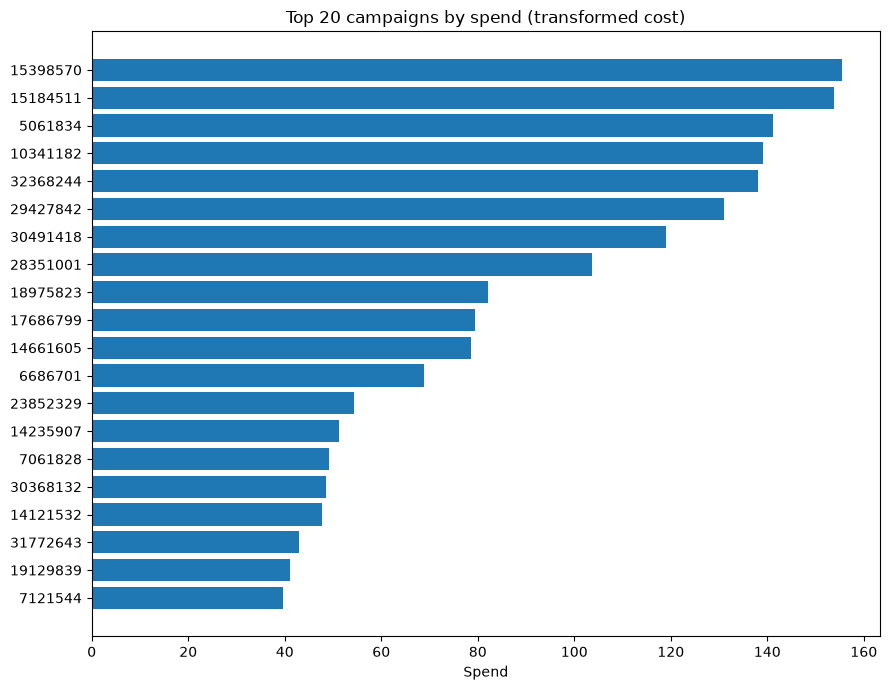

In [5]:
top = stable.nlargest(20, "spend").sort_values("spend")
fig, ax = plt.subplots(figsize=(9,7))
ax.barh(top.campaign.astype(str), top.spend)
ax.set_title("Top 20 campaigns by spend (transformed cost)")
ax.set_xlabel("Spend")
plt.tight_layout(); plt.savefig(OUT + "top20_spend.png", dpi=150); plt.show()

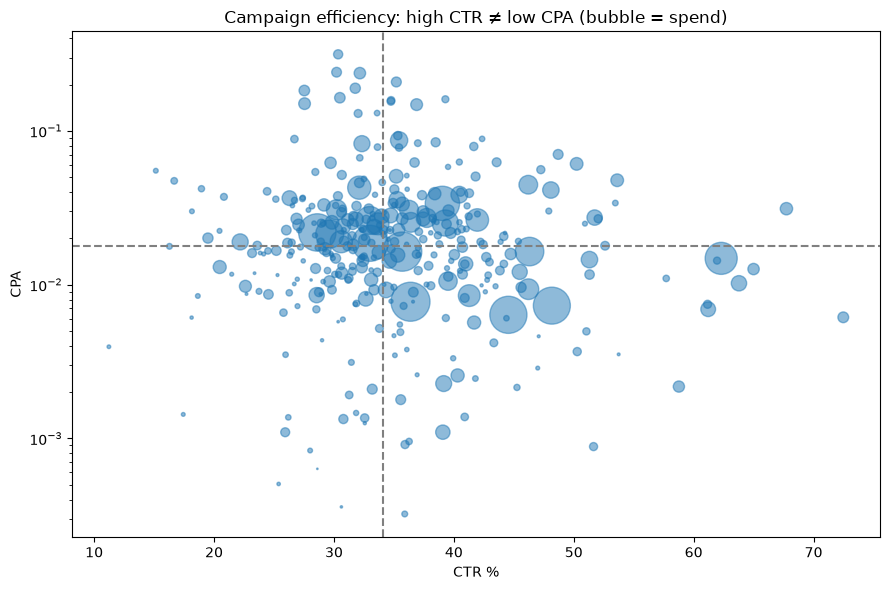

Correlation CTR vs CPA: -0.059


In [6]:
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(stable.ctr*100, stable.cpa, s=stable.spend/stable.spend.max()*800, alpha=0.5)
ax.axvline(stable.ctr.median()*100, ls="--", c="grey")
ax.axhline(stable.cpa.median(), ls="--", c="grey")
ax.set_xlabel("CTR %"); ax.set_ylabel("CPA"); ax.set_yscale("log")
ax.set_title("Campaign efficiency: high CTR ≠ low CPA (bubble = spend)")
plt.tight_layout(); plt.savefig(OUT + "ctr_vs_cpa.png", dpi=150); plt.show()

print("Correlation CTR vs CPA:", stable[["ctr","cpa"]].corr().iloc[0,1].round(3))

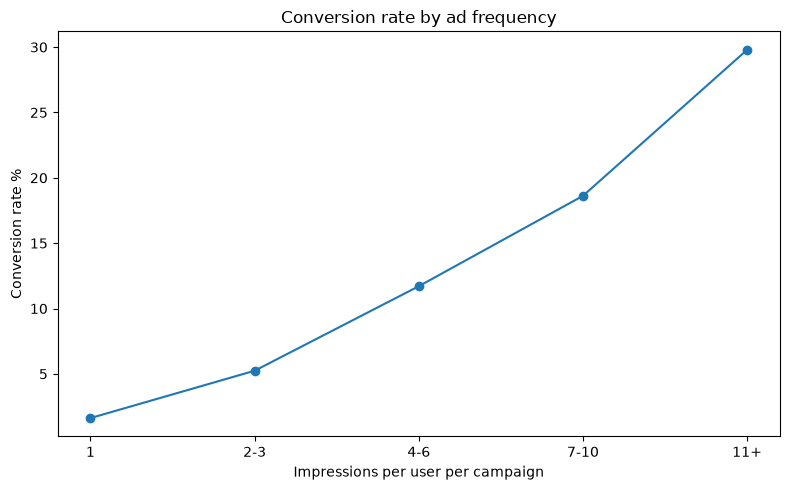

,bucket,sort_key,user_campaign_pairs,conv_rate_pct
0,1,1,4900078,1.620219
1,2-3,2,1926725,5.242160
2,4-6,4,623587,11.707428
3,7-10,7,222051,18.620947
4,11+,11,140960,29.795687


In [7]:
freq = con.sql("""
SELECT
  CASE WHEN n=1 THEN '1' WHEN n<=3 THEN '2-3' WHEN n<=6 THEN '4-6'
       WHEN n<=10 THEN '7-10' ELSE '11+' END AS bucket,
  MIN(n) AS sort_key,
  COUNT(*) AS user_campaign_pairs,
  AVG(converted) * 100 AS conv_rate_pct
FROM (SELECT uid, campaign, COUNT(*) AS n,
             MAX(CASE WHEN conversion_id <> -1 THEN 1 ELSE 0 END) AS converted
      FROM raw GROUP BY uid, campaign)
GROUP BY bucket ORDER BY sort_key
""").df()
freq.to_csv(OUT + "frequency_curve.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(freq.bucket, freq.conv_rate_pct, marker="o")
ax.set_xlabel("Impressions per user per campaign"); ax.set_ylabel("Conversion rate %")
ax.set_title("Conversion rate by ad frequency")
plt.tight_layout(); plt.savefig(OUT + "frequency_curve.png", dpi=150); plt.show()
freq

       days_first_touch  days_last_touch
count         435810.00        435810.00
mean               6.94             5.06
std                8.76             7.69
min                0.00             0.00
25%                0.01             0.00
50%                2.71             0.87
75%               11.84             7.18
max               58.65            30.00


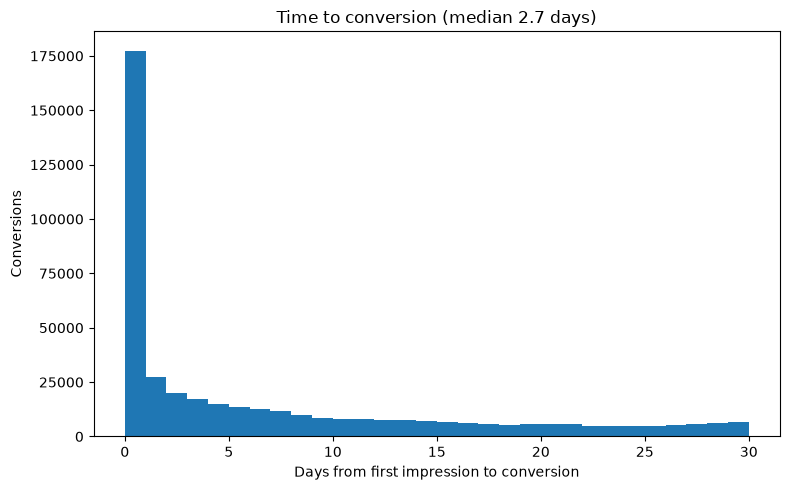

In [8]:
ttc = con.sql("""
SELECT conversion_id,
  (MAX(conversion_timestamp) - MIN(timestamp)) / 86400.0 AS days_first_touch,
  (MAX(conversion_timestamp) - MAX(timestamp)) / 86400.0 AS days_last_touch
FROM raw WHERE conversion_id <> -1
GROUP BY conversion_id
""").df()

print(ttc[["days_first_touch","days_last_touch"]].describe().round(2))
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(ttc.days_first_touch.clip(upper=30), bins=30)
ax.set_xlabel("Days from first impression to conversion"); ax.set_ylabel("Conversions")
ax.set_title(f"Time to conversion (median {ttc.days_first_touch.median():.1f} days)")
plt.tight_layout(); plt.savefig(OUT + "time_to_conversion.png", dpi=150); plt.show()